In [ ]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


#LOAD/PREPROCESS DATA
data = pd.read_csv("kmData.csv")
data = data.drop('Iterations', axis=1)
X = data.drop(['GPU'], axis=1)
y = data['GPU']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.fit_transform(X_test)

cols = ['total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

features = ['elements','clusters', 'blocks', 'threadsPerBlock',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']



device_specs = data[cols].drop_duplicates().to_numpy()

#device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [25]:
# model = XGBRegressor()
model = XGBRegressor(
    n_estimators=10000,
    max_depth = 8,
    learning_rate=0.1,
    random_state=42)

model.fit(X_train, y_log) #train on y_log instead of y_train to restrict the predicted compute times to be >0

preds_log = model.predict(X_test)
preds = np.exp(preds_log) #revert back from log of predicted time
preds[:6], y_test.to_numpy()[:6]

(array([  0.184791, 106.7779  ,   0.295337,   0.160377,   0.094809,
          0.716405], dtype=float32),
 array([ 0.18544 , 87.758503,  0.337923,  0.15744 ,  0.096464,  0.778648]))

In [26]:
blocks = np.array([32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768])
threads = np.array([32, 50, 64, 100, 128, 200, 256, 400, 512, 750, 1024])
num_elements = 100000
clusters = 10

results = []
for b in blocks:
    for t in threads:

        #concatenate [elements, blocks, TPB] with rest of inputs (8,)
        #try with device_specs[x], x \in {0, 1, 2, 3}
        input_features = np.concatenate([np.array([num_elements, clusters, b, t], dtype='float64'), device_specs[2]]).reshape(-1, 12)
        
        #model was trained on log values, need to exponentiate once prediction is made
        res = np.exp(model.predict(input_features))

        results.append([b, t, res[0]])

results = np.array(results)
sorted = results[results[:, 2].argsort()] #sort array to determine the number of blocks and TPB with lowest runtimes 

min_b, min_tpb, min_time = results[np.argmin(results[:, 2])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Time: {min_time:.6f}s')

print("\nBest device: cuda4")
print("Device Specs:\n")

for name, spec in zip(cols, device_specs[2]):
    print(f'{name}: {spec}')

Best Config:
Blocks: 512 | Threads Per Block: 256 | Time: 0.097350s

Best device: cuda4
Device Specs:

total global memory(KB): 12492800
clock rate(KHz): 1215500
multiprocessor count: 24
async engine count: 2
memory bus width: 384
memory clock rate (KHz): 3505000
L2 cache size (bytes): 3145728
max threads per SM: 2048


In [18]:
print('Top 10 Best Configurations:')

for s in range(10):
    nb, tpb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Time: {time:.6f}s')

#Compare with test set
sorted_df = data[(data['elements'] == num_elements) & (data['clusters'] == clusters)].sort_values(by='GPU')
sorted_df.head(10)

Top 10 Best Configurations:
Blocks: 512 | Threads Per Block: 400 | Time: 0.110178s
Blocks: 128 | Threads Per Block: 128 | Time: 0.110423s
Blocks: 128 | Threads Per Block: 200 | Time: 0.110512s
Blocks: 512 | Threads Per Block: 200 | Time: 0.110651s
Blocks: 512 | Threads Per Block: 256 | Time: 0.110745s
Blocks: 4096 | Threads Per Block: 32 | Time: 0.111030s
Blocks: 128 | Threads Per Block: 400 | Time: 0.111296s
Blocks: 128 | Threads Per Block: 256 | Time: 0.111298s
Blocks: 2048 | Threads Per Block: 256 | Time: 0.111453s
Blocks: 64 | Threads Per Block: 200 | Time: 0.111463s


,elements,clusters,blocks,threadsPerBlock,GPU,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM
9557,100000,10,512,200,0.097541,12492800,1215500,24,2,384,3505000,3145728,2048
9561,100000,10,512,750,0.097713,12492800,1215500,24,2,384,3505000,3145728,2048
9559,100000,10,512,400,0.097898,12492800,1215500,24,2,384,3505000,3145728,2048
9562,100000,10,512,1024,0.098315,12492800,1215500,24,2,384,3505000,3145728,2048
9558,100000,10,512,256,0.098909,12492800,1215500,24,2,384,3505000,3145728,2048
9560,100000,10,512,512,0.099747,12492800,1215500,24,2,384,3505000,3145728,2048
9579,100000,10,2048,200,0.104100,12492800,1215500,24,2,384,3505000,3145728,2048
9578,100000,10,2048,128,0.105103,12492800,1215500,24,2,384,3505000,3145728,2048
9580,100000,10,2048,256,0.105235,12492800,1215500,24,2,384,3505000,3145728,2048
9581,100000,10,2048,400,0.105423,12492800,1215500,24,2,384,3505000,3145728,2048


In [19]:
#Compare with Ground Truth for 100k Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best observed overall performance (cuda3 in this case)

gt = pd.read_csv('kmGT100k.csv').drop('Iterations', axis=1)
gt = gt.groupby(['blocks', 'threadsPerBlock']).mean().reset_index().sort_values('GPU')
gt.head(10)

,blocks,threadsPerBlock,elements,clusters,GPU
13,64,64,100000.0,10.0,0.108448
9,32,750,100000.0,10.0,0.109362
10,32,1024,100000.0,10.0,0.109697
8,32,512,100000.0,10.0,0.109765
22,128,32,100000.0,10.0,0.110284
14,64,100,100000.0,10.0,0.110303
3,32,100,100000.0,10.0,0.110585
2,32,64,100000.0,10.0,0.110899
12,64,50,100000.0,10.0,0.111049
1,32,50,100000.0,10.0,0.111108


In [12]:
gt['threadsPerBlock'].unique()

array([  64,  750, 1024,  512,   32,  100,   50,  256,  128,  200,  400],
      dtype=int64)


Top 5 most important features (XGBoost):
                   Feature  Importance
2  total global memory(KB)    0.084224
0                   blocks    0.011135
1          threadsPerBlock    0.009484
4     multiprocessor count    0.001122
3          clock rate(KHz)    0.000000

Top 5 most important features (SHAP):
                   Feature  SHAP_Importance
2  total global memory(KB)         0.178197
0                   blocks         0.079045
1          threadsPerBlock         0.052490
4     multiprocessor count         0.004572
3          clock rate(KHz)         0.000000


<Figure size 1000x500 with 0 Axes>

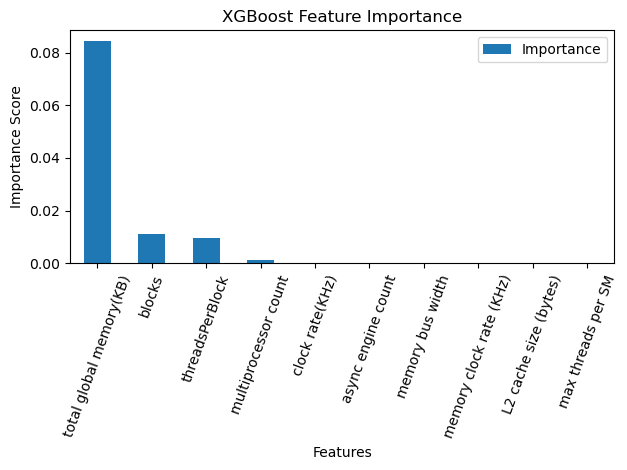

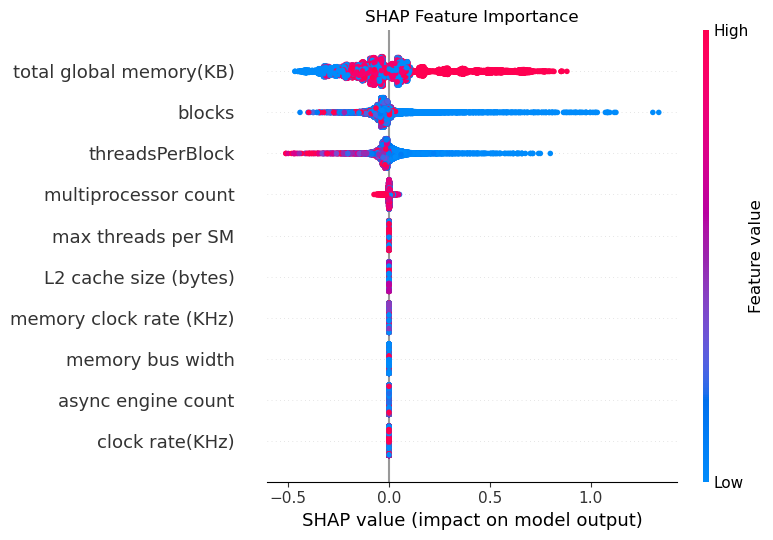

In [6]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    """
    Analyze feature importance using XGBoost and SHAP, with option to exclude multiple features.
    
    Parameters:
    - model: Trained XGBoost model
    - X_train: Training data
    - exclude: Single feature name/index or list of feature names/indices to exclude
    - feature_names: List of feature names (optional)
    
    Returns:
    Dictionary containing feature importance results and visualization figures
    """
    # Convert exclude to a list if it's not already
    if isinstance(exclude, (str, int)):
        exclude = [exclude]
    
    # Handle feature name indexing
    if feature_names is not None:
        # Convert feature names to indices if strings are provided
        exclude_indices = [feature_names.index(feat) if isinstance(feat, str) else feat for feat in exclude]
    else:
        # If no feature names, assume exclude contains direct indices
        exclude_indices = exclude
    
    # Create a mask of features to keep
    keep_mask = np.ones(len(feature_names), dtype=bool)
    keep_mask[exclude_indices] = False
    
    # Get include names and indices
    include_names = [name for name, keep in zip(feature_names, keep_mask) if keep]
    
    # XGBoost Feature Importance
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(feature_names, importance_values) 
        if name not in [feature_names[idx] for idx in exclude_indices]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    # SHAP Analysis
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # Filter training data and SHAP values
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.loc[:, include_names]
    else:
        X_train_filtered = X_train[:, keep_mask]
    
    shap_values_filtered = shap_values[:, keep_mask]
    
    # Mean absolute SHAP values
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    
    # XGBoost Importance Plot
    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    # SHAP Summary Plot
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                      feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

# Example usage
results = analyze_feature_importance(model, X_train, exclude=['elements', 'clusters'], feature_names=features)
print("\nTop 5 most important features (XGBoost):") 
print(results['xgboost_importance'].head())
print("\nTop 5 most important features (SHAP):") 
print(results['shap_importance'].head())
plt.show()